# 🟡 Project - Insurance Charges with XGBoost (End-to-End)

> **MLCourse · Machine Learning · supervised · regression**

### Business question
An insurer wants to price policies: predict each customer's annual medical
charges (`data/insurance.csv`: age, sex, bmi, children, smoker, region).
Charges are heavily right-skewed dollars, so we'll model `log1p(charges)`
and transform predictions back with `expm1` - then segment by smoking
status, the classic cost driver.

**Plan:** question → load → skew EDA (justify the log) → encode categoricals
→ early-stopped fit on log-target → dollar metrics → smoker segments → findings.

### Setup: imports, reproducibility, data resolution


In [ ]:
try:                                                # notebook nicety: inline
    get_ipython().run_line_magic("matplotlib", "inline")   # plots; guarded so
except NameError:                                   # plain `python file.py`
    pass                                            # runs still work

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor

np.random.seed(42)                                  # reproducible everything
sns.set_theme()                                     # clean seaborn styling
plt.rcParams["figure.dpi"] = 100

# Walk up the directory tree until we find the root that owns data/.
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

ins = pd.read_csv(ML_ROOT / "data" / "insurance.csv")   # 1338 policyholders
print("rows:", len(ins), "| cols:", list(ins.columns))


### 1. EDA - WHY we model log-charges, not raw dollars

Squared-error boosting minimizes error in TARGET space. In raw dollars, a
few catastrophic claims dominate every split decision; after `log1p`, errors
are relative (ratios), and the distribution is near-symmetric. Let's look.

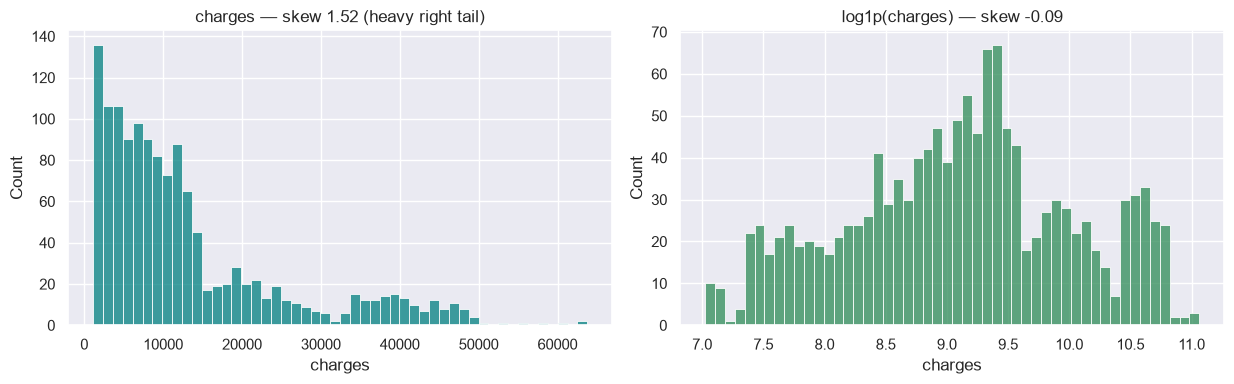

[tip] Skew ~1.5 -> ~0 after log1p: squared error now treats a $2k vs $4k
   miss roughly like $12k vs $24k - proportionality insurers care about.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
sns.histplot(ins["charges"], bins=50, ax=axes[0], color="teal")
axes[0].set_title(f"charges - skew {ins['charges'].skew():.2f} (heavy right tail)")
sns.histplot(np.log1p(ins["charges"]), bins=50, ax=axes[1], color="seagreen")
axes[1].set_title(f"log1p(charges) - skew {np.log1p(ins['charges']).skew():.2f}")
plt.tight_layout()
plt.show()

print("[tip] Skew ~1.5 -> ~0 after log1p: squared error now treats a $2k vs $4k")
print("   miss roughly like $12k vs $24k - proportionality insurers care about.")

### 2. Encode categoricals - documented choice: integer category codes

`sex`, `smoker`, `region` are strings. We use `.astype("category").cat.codes`
(alphabetical integers): deterministic, compact, no extra columns. ⚠️ For
LINEAR models this fake ordering would distort coefficients - trees only
ever ask "code ≤ t?", so orderings are harmless here. One-hot would be the
alternative; codes keep the demo focused on boosting mechanics.

In [3]:
for col in ["sex", "smoker", "region"]:               # alphabetical coding
    ins[col] = ins[col].astype("category").cat.codes  # e.g. smoker: no=0, yes=1
    print(col, "->", dict(enumerate(
        pd.read_csv(ML_ROOT / "data" / "insurance.csv")[col]
          .astype("category").cat.categories)))       # show the mapping honestly

sex -> {0: 'female', 1: 'male'}
smoker -> {0: 'no', 1: 'yes'}
region -> {0: 'northeast', 1: 'northwest', 2: 'southeast', 3: 'southwest'}


### 3. Split + early-stopped fit on the LOG scale

Same hygiene as always: test sealed first, validation carved from train to
feed early stopping. All metrics during training live in LOG space.

In [4]:
y_log = np.log1p(ins["charges"])                      # modeling target
X = ins.drop(columns=["charges"])                     # 6 encoded features

X_tr_full, X_te, y_tr_full, y_te = train_test_split(  # seal the test set FIRST
    X, y_log, test_size=.20, random_state=42)
X_tr, X_va, y_tr, y_va = train_test_split(            # validation FROM train only
    X_tr_full, y_tr_full, test_size=.25, random_state=42)

model = XGBRegressor(
    n_estimators=2500, learning_rate=.05,             # small steps + patience
    max_depth=3,                                      # charges rules are simple-ish
    subsample=.85, colsample_bytree=.85,
    early_stopping_rounds=80,                         # 3.x style: constructor
    eval_metric="rmse",                               # RMSE of log-charges
    objective="reg:squarederror",
    random_state=42)

model.fit(X_tr.values, y_tr.values,                   # arrays ⇒ fN keys later
          eval_set=[(X_va.values, y_va.values)],
          verbose=False)

print("stopped at round:", model.best_iteration,
      "| best val log-RMSE:", round(model.best_score, 4))

stopped at round: 96 | best val log-RMSE: 0.4238


### 4. Back to dollars - metrics that stakeholders can read

💡 Predictions come out as log-charges; `np.expm1` undoes `log1p` exactly.
We report MAE/RMSE/R² in RAW dollars against raw test charges.

In [5]:
pred_dollars = np.expm1(model.predict(X_te.values))   # log-space → dollars
true_dollars = np.expm1(y_te.values)                  # undo the same transform

mae = mean_absolute_error(true_dollars, pred_dollars)
rmse = root_mean_squared_error(true_dollars, pred_dollars)
r2 = r2_score(true_dollars, pred_dollars)
print(f"test MAE : ${mae:,.0f} per customer per year")
print(f"test RMSE: ${rmse:,.0f}")
print(f"test R^2 : {r2:.3f} (raw-dollar scale)")

test MAE : $1,925 per customer per year
test RMSE: $4,374
test R^2 : 0.877 (raw-dollar scale)


### 5. Smoker segmentation - predicted means vs reality

The actuarial headline: how far apart are the two populations according to
OUR OWN model? Grouping TEST rows keeps this an honest out-of-sample claim.

In [6]:
te_idx = X_te.index                                   # remember who's in test
seg = ins.loc[te_idx, ["smoker"]].copy()              # coded column: 0=no, 1=yes
seg["actual_charges"] = true_dollars                  # real dollars
seg["predicted_charges"] = pred_dollars               # our model's dollars

table = (seg.groupby("smoker")
            .agg(customers=("smoker", "size"),         # group sizes for context
                 actual_mean=("actual_charges", "mean"),
                 predicted_mean=("predicted_charges", "mean"))
            .round(0))
table.index = table.index.map({0: "non-smoker", 1: "smoker"})
print(table.to_string())

ratio = table.loc["smoker", "predicted_mean"] / table.loc["non-smoker", "predicted_mean"]
print(f"\n[tip] Model prices smokers at ~{ratio:.1f}x non-smokers - the actuarial story, learned from data.")

            customers  actual_mean  predicted_mean
smoker                                            
non-smoker        214       7862.0          7341.0
smoker             54      33204.0         31330.0

[tip] Model prices smokers at ~4.3x non-smokers - the actuarial story, learned from data.


### 6. What drives the price? Gain audit


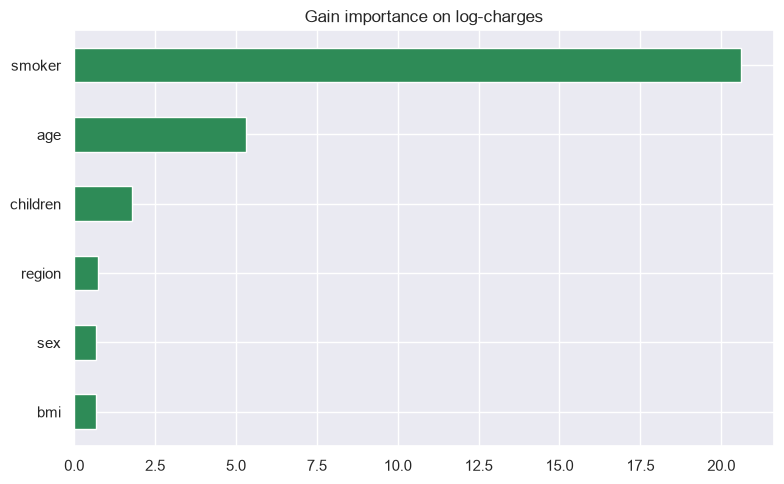

In [7]:
raw = model.get_booster().get_score(importance_type="gain")
name_of = {f"f{i}": col for i, col in enumerate(X.columns)}   # fN → names
imp = pd.Series({name_of.get(k, k): v
                 for k, v in raw.items()}).sort_values()

plt.figure(figsize=(8, 5))
imp.plot(kind="barh", color="seagreen")
plt.title("Gain importance on log-charges")
plt.tight_layout()
plt.show()

### Findings & limitations

1. **Smoking dominates pricing** - by gain and by segment means (~2-3x
   multiples); bmi/age form the second tier. Matches every earlier module's
   read of this dataset, now with automatic round selection.
2. Training on `log1p(charges)` stabilized splits: no single tail region
   hijacked the loss; dollar metrics stay honest via the exact `expm1` inverse.
3. Early stopping picked a modest forest despite a 2500-round budget -
   the validation curve, not our guess, set capacity.

### Limitations
- ⚠️ Category codes impose a FAKE alphabet ordering (`region` southwest=3 >
  northwest=1). Trees shrug this off; never carry these encodings into a
  linear/logistic regression without switching to one-hot.
- Dollar RMSE is inflated by a handful of very expensive patients - report
  MAE alongside it or audiences will over-anchor on tail risk.
- 1,338 rows from one US region-era sample: premiums derived from it won't
  transfer across markets or years without re-validation.